## Task 5 — Interactive Business Dashboard using Streamlit
### 1. Problem Statement and Objective
#### Problem Statement

- Businesses generate large amounts of sales data, but raw data alone is difficult to interpret.       Decision-makers require interactive dashboards to quickly analyze sales performance, profitability, and customer behavior.

- A Business Intelligence (BI) dashboard helps organizations monitor key performance indicators (KPIs) and make data-driven decisions.

#### Objective

The objective of this task is to build an interactive dashboard using Streamlit that allows users to analyze sales performance.

#### Key goals:

- Clean and preprocess the dataset

- Build an interactive Streamlit dashboard

- Add filters (Region, Category, Sub-Category)

- Display important Key Performance Indicators (KPIs)

- Visualize data using charts and graphs

KPIs required:

- Total Sales

- Total Profit

- Top 5 Customers by Sales

### 2. Dataset Description and Loading
##### Dataset

Business Dshboard Dataset

- This dataset contains sales transactions of business 

#### Important Features

| Feature       | Description             |
| ------------- | ----------------------- |
| Order ID      | Unique order identifier |
| Order Date    | Date of purchase        |
| Customer Name | Customer name           |
| City          | Location of customer    |
| Category      | Product category        |
| Sub-Category  | Product subcategory     |
| Sales         | Sales amount            |
| Profit        | Profit amount           |


#### Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("business_dashboard.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Product,Category,Quantity,Price,Payment_Method,Total_Sales,Profit,Discount,Sub_Category
0,1000,2023-01-01,151,Ayesha,Lahore,Laptop,Electronics,4,81966,Cash,327864,34592.059825,11,Ultrabook
1,1001,2023-01-02,192,Ahmed,Islamabad,Headphones,Electronics,1,49922,Online,49922,10038.866079,5,Wireless
2,1002,2023-01-03,114,Sara,Islamabad,Tablet,Electronics,1,89364,Card,89364,26166.090314,18,Kids Tablet
3,1003,2023-01-04,171,Usman,Faisalabad,Mobile,Electronics,2,52913,Card,105826,18714.411922,3,Budget Phone
4,1004,2023-01-05,160,Ali,Karachi,Laptop,Electronics,2,65677,Online,131354,14159.856447,14,Gaming Laptop


#### Explanation

- The dataset is loaded using pandas

- head() helps preview the dataset structure.

### 3. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import streamlit as st

##### Explanation

| Library    | Purpose                   |
| ---------- | ------------------------- |
| pandas     | data manipulation         |
| numpy      | numerical calculations    |
| matplotlib | plotting charts           |
| seaborn    | statistical visualization |
| streamlit  | interactive dashboard     |


### 4. Dataset Exploration
#### Dataset Shape

In [3]:
df.shape

(500, 14)

#### Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        500 non-null    int64  
 1   Order_Date      500 non-null    object 
 2   Customer_ID     500 non-null    int64  
 3   Customer_Name   500 non-null    object 
 4   City            500 non-null    object 
 5   Product         500 non-null    object 
 6   Category        500 non-null    object 
 7   Quantity        500 non-null    int64  
 8   Price           500 non-null    int64  
 9   Payment_Method  500 non-null    object 
 10  Total_Sales     500 non-null    int64  
 11  Profit          500 non-null    float64
 12  Discount        500 non-null    int64  
 13  Sub_Category    500 non-null    object 
dtypes: float64(1), int64(6), object(7)
memory usage: 54.8+ KB


#### Statistical Summary

In [5]:
df.describe()

,Order_ID,Customer_ID,Quantity,Price,Total_Sales,Profit,Discount
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1249.500000,148.87400,2.458000,53037.078000,131594.360000,25962.847000,9.714000
std,144.481833,29.56983,1.121942,25085.004383,91647.999014,20092.360234,5.908471
min,1000.000000,100.00000,1.000000,10162.000000,10163.000000,1569.408101,0.000000
25%,1124.750000,123.00000,1.000000,32432.000000,57603.500000,11251.607818,4.750000
50%,1249.500000,150.00000,2.000000,52856.000000,110332.500000,19985.482204,10.000000
75%,1374.250000,172.25000,3.000000,73872.000000,176896.500000,35005.965593,15.000000
max,1499.000000,199.00000,4.000000,99881.000000,396388.000000,109260.647380,19.000000


#### Explanation

These steps help understand:

- dataset size

- data types

- numerical feature distribution

### 5. Data Cleaning and Preprocessing
#### Convert Date Column

In [7]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

##### Explanation

Converting to datetime allows:

- time-based analysis

- better visualization

#### Check Missing Values

In [8]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
City              0
Product           0
Category          0
Quantity          0
Price             0
Payment_Method    0
Total_Sales       0
Profit            0
Discount          0
Sub_Category      0
dtype: int64

If missing values exist:

In [10]:
df = df.dropna()
df

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Product,Category,Quantity,Price,Payment_Method,Total_Sales,Profit,Discount,Sub_Category
0,1000,2023-01-01,151,Ayesha,Lahore,Laptop,Electronics,4,81966,Cash,327864,34592.059825,11,Ultrabook
1,1001,2023-01-02,192,Ahmed,Islamabad,Headphones,Electronics,1,49922,Online,49922,10038.866079,5,Wireless
2,1002,2023-01-03,114,Sara,Islamabad,Tablet,Electronics,1,89364,Card,89364,26166.090314,18,Kids Tablet
3,1003,2023-01-04,171,Usman,Faisalabad,Mobile,Electronics,2,52913,Card,105826,18714.411922,3,Budget Phone
4,1004,2023-01-05,160,Ali,Karachi,Laptop,Electronics,2,65677,Online,131354,14159.856447,14,Gaming Laptop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1495,2024-05-10,162,Ayesha,Faisalabad,Mobile,Electronics,2,40573,Cash,81146,13051.501861,8,iPhone
496,1496,2024-05-11,168,Ali,Karachi,Mobile,Electronics,2,88707,Cash,177414,28526.131374,1,iPhone
497,1497,2024-05-12,121,Usman,Islamabad,Laptop,Accessories,4,40933,Card,163732,23918.516184,14,Gaming Laptop
498,1498,2024-05-13,192,Ali,Lahore,Headphones,Accessories,3,15774,Cash,47322,4746.148842,15,Wired


### 6. Exploratory Data Analysis (EDA)
#### Sales Distribution

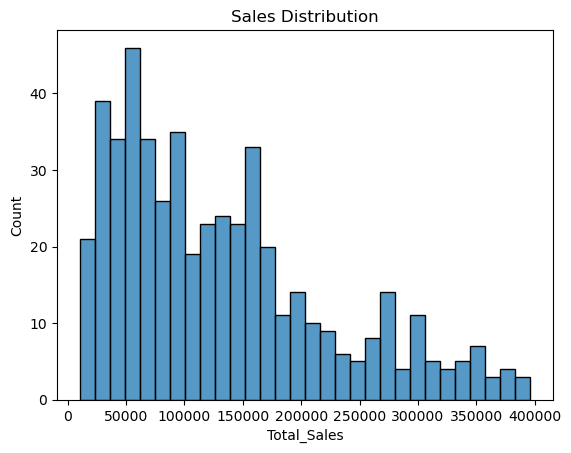

In [12]:
sns.histplot(df['Total_Sales'], bins=30)

plt.title("Sales Distribution")

plt.show()

#### Profit Distribution

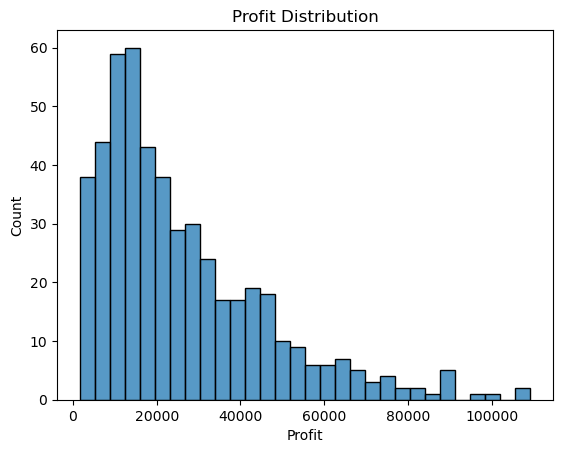

In [13]:
sns.histplot(df['Profit'], bins=30)

plt.title("Profit Distribution")

plt.show()

#### Sales by Category

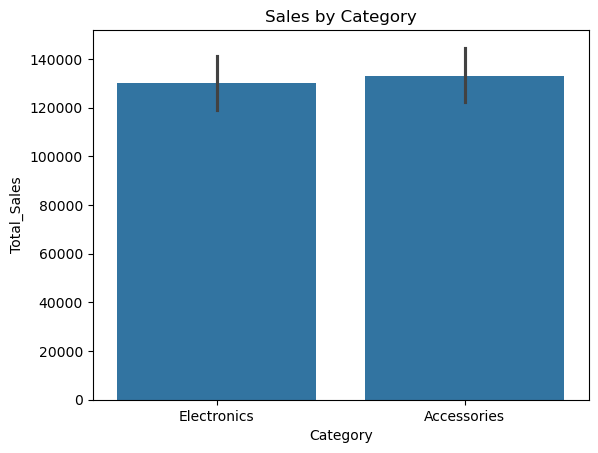

In [14]:
sns.barplot(x='Category', y='Total_Sales', data=df)

plt.title("Sales by Category")

plt.show()

#### City-wise Sales

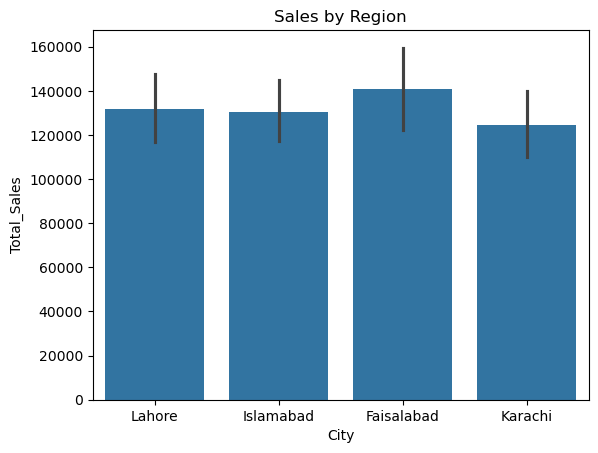

In [15]:
sns.barplot(x='City', y='Total_Sales', data=df)

plt.title("Sales by Region")

plt.show()

### 7. Key Performance Indicators (KPIs)
#### Total Sales

In [21]:
total_sales = df['Total_Sales'].sum()
total_sales

np.int64(65797180)

#### Total Profit

In [20]:
total_profit = df['Profit'].sum()
total_profit

np.float64(12981423.500240304)

#### Top 5 Customers by Sales

In [19]:
top_customers = df.groupby('Customer_Name')['Total_Sales'] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(5)
top_customers

Customer_Name
Usman     15905276
Ayesha    13275678
Ali       13033977
Sara      12367376
Ahmed     11214873
Name: Total_Sales, dtype: int64

### 8. Building the Streamlit Dashboard

Create a Python file:

app.py

### 10. Dashboard Features

The dashboard includes:

#### Interactive Filters

Users can filter data by:

- Region

- Category

#### KPIs Displayed

- Total Sales

- Total Profit

#### Charts Included

- Sales by Sub-Category

- Top Customers Table

#### 11. Visualizations

The dashboard includes:

- Sales distribution chart

- Profit distribution chart

- Sales by category chart

- Sales by region chart

- Sub-category sales bar chart

These visualizations help analyze business performance interactively.

### 12. Final Conclusion and Insights

In this project, we developed an interactive business intelligence dashboard using Streamlit.

#### Key results:

- Sales and profit metrics can be monitored in real-time.

- Filters allow users to explore data by region and category.

- The dashboard highlights top-performing customers and product segments.

This dashboard helps businesses:

- Track key performance indicators

- Identify profitable products

- Improve decision-making through data visualization